In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from matplotlib import pyplot as plt
from sklearn.model_selection import GridSearchCV # For hyperparameter tuning 

# # I'll be going preprocessing data for a supervised machine learning task.
# # Load the dataset
# titanic_data = pd.read_csv('csv_files/bios.csv', sep=',')
# # get_dummies is a crucial function in pandas for converting categorical variables into a format(strings to numbers) that can be provided to ML algorithms to do a better job in prediction.
# titanic_data = pd.get_dummies(titanic_data, columns=['born_city'], drop_first=True) # drop_first=True to avoid the dummy variable trap
# titanic_data.head()

x, y = make_classification(n_samples=90000, n_features=18, n_informative=4, n_redundant=12, random_state=42)
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.3)

train_scores, test_scores = [], []
depths = range(1, 21)

# for depth in depths:
#     model = DecisionTreeClassifier(max_depth=depth)
#     model.fit(xtrain, ytrain)
#     train_pred = model.predict(xtrain)
#     test_pred = model.predict(xtest)
#     train_accuracy = accuracy_score(ytrain, train_pred)
#     test_accuracy = accuracy_score(ytest, test_pred)
#     train_scores.append(train_accuracy)
#     test_scores.append(test_accuracy)
#     # print(f"Depth: {depth}, Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")

# plt.plot(depths, train_scores, label='Train Accuracy', marker='o' )
# plt.plot(depths, test_scores, label='Test Accuracy', marker='o')
# plt.legend()

param_grid = {'criterion': ['gini', 'entropy'], 'max_depth': range(1, 21), 'min_samples_split': range(2, 11)} # Hyperparameter grid used for evaluating the multiple parameters in succession and finding the best combination.

new_model = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, scoring="accuracy", n_jobs=-1)
new_model.fit(xtrain, ytrain)
best_model = new_model.best_estimator_
print("Best Hyperparameters:", new_model.best_params_)
print(f"For training data, best model accuracy: {accuracy_score(ytrain, best_model.predict(xtrain)):.4f}")
print(f"For test data, best model accuracy: {accuracy_score(ytest, best_model.predict(xtest)):.4f}")

In [ ]:
# Linear regression
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score

housing_data = fetch_california_housing()
housing = pd.DataFrame(data=housing_data.data, columns=housing_data.feature_names)
housing['House_Price'] = housing_data.target
print(housing.isna().sum())
print(housing.head())
#Visualizing the diffeerent realtionships between the features and the target variable
sns.pairplot(housing, x_vars=housing_data.feature_names, y_vars='House_Price', height=3)
housing.plot(kind='scatter', x='Longitude', y='Latitude', alpha=0.2, s = housing['Population']/100, c='House_Price', cmap=plt.get_cmap('jet'), colorbar=True, figsize=(10,8))

# Collinearity means that two or more predictor variables in a multiple regression model are highly correlated, meaning that one can be linearly predicted from the others with a substantial degree of accuracy. 

# This can lead to problems in estimating the coefficients of the regression model, as it becomes difficult to determine the individual effect of each predictor on the response variable. 

# Heatmap to show the correlation between different features
correlation = housing.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
print(correlation['House_Price'].abs().sort_values(ascending=False))

# Scatter plot to show the relationship between Median Income and House Price since they have a high correlation
medIncome = housing['MedInc']
housePrice = housing['House_Price']
plt.scatter(medIncome, housePrice, alpha=0.4, color='blue')
plt.xlabel('Median Income')
plt.ylabel('House Price')
plt.title('Median Income vs House Price')
plt.grid(True)



# One common method to detect multicollinearity is by calculating the 
# VIF (Variance Inflation Factor) that measures how much the variance of a regression coefficient is inflated due to multicollinearity with other predictors. 
housing_vif = housing.drop(columns=['House_Price'])
housing_vif = housing_vif.apply(pd.to_numeric, errors='coerce') # Ensure all data is numeric
print(housing_vif)
print("---------------")   
print(housing_vif.to_numpy())   
vif_data = pd.DataFrame()
vif_data['Feature'] = housing_vif.columns
vif_data['VIF'] = [VIF(housing_vif.to_numpy(), i) for i in range(len(housing_vif.columns))]
print("VIF Data:", vif_data) # Display VIF values for each feature

# Now we drop the features with high VIF values (commonly above 5 or 10)
housing_reduced = housing.drop(columns=['Longitude', 'Latitude']) # Dropping features with high VIF values
cols = housing_reduced.columns.tolist()
cols.remove('House_Price')
# print(cols)
housing_reduced[cols] = housing_reduced[cols].apply(pd.to_numeric, errors='coerce') # Ensure all data is numeric
housing['House_Price'] = housing['House_Price'].apply(pd.to_numeric, errors='coerce')

# Building the regression model
x = sm.add_constant(housing_reduced) # Adding a constant term for the intercept
# print(x.head())
y = housing_reduced['House_Price']
# print(y.head())
model = sm.OLS(y, x).fit()
# print(model.summary())

#Residual analysis. Rediduals are the differences between the observed values and the values predicted by the model. 
residuals = model.resid
print(residuals.head())

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.histplot(residuals, kde=True) # Plotting the distribution of residuals to check for normality
plt.title('Residuals Distribution')
plt.subplot(1,2,2)
plt.scatter(model.predict(x), residuals, alpha=0.5) # Plotting residuals vs fitted values to check for homoscedasticity
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.ylabel('Residuals')
plt.xlabel('Fitted Values')
plt.tight_layout()

print("Model coefficients:", model.params)

# Evaluation of the model
y_pred = model.predict(x)
print("Mean Squared Error:", mean_squared_error(y, y_pred))
print("R-squared Score:", r2_score(y, y_pred))
print(housing.describe())

# Visualization of outliers using box plots
def plot_boxplots(data):
    fig, axs = plt.subplots(1, len(data.columns), figsize=(20, 5))
    for i, column in enumerate(data.columns):
        data.boxplot(column=column, ax=axs[i])
        axs[i].set_title(f'Box plot of {column}')
    
    plt.show()

# plot_boxplots(housing_reduced)

# Remove outliers using the upper and lower bound method (IQR method)
def remove_outliers_iqr(data):
    copy = data.copy() # Create a copy to preserve the original data
    for column in data.columns:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # copy = copy[(copy[column] >= lower_bound) & (copy[column] <= upper_bound)] # This line removes the outliers completely
        # Instead of removing, we can cap the outliers to the bounds
        copy[column] = copy[column].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)
    return copy
      

# plot_boxplots(remove_outliers_iqr(housing_reduced)) # Plot box plots after removing outliers
new_housing_reduced = remove_outliers_iqr(housing_reduced)
plot_boxplots(new_housing_reduced)
cols = new_housing_reduced.columns.tolist()
cols.remove('House_Price')
new_housing_reduced[cols] = new_housing_reduced[cols].apply(pd.to_numeric, errors='coerce') # Ensure all data is numeric
new_housing_reduced['House_Price'] = new_housing_reduced['House_Price'].apply(pd.to_numeric, errors='coerce')
x_new = sm.add_constant(new_housing_reduced.drop(columns="House_Price"))
y_new = new_housing_reduced['House_Price']
new_model = sm.OLS(y_new, x_new).fit()

new_residuals = new_model.resid 
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.histplot(new_residuals, kde=True) # Plotting the distribution of residuals to check for normality
plt.title('Residuals Distribution After Outlier Removal')
plt.subplot(1,2,2)
plt.scatter(new_model.predict(x_new), new_residuals, alpha=0.5) # Plotting residuals vs fitted values to check for homoscedasticity
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values After Outlier Removal')
plt.ylabel('Residuals')
plt.xlabel('Fitted Values')
plt.tight_layout()
plt.show()

print(new_model.params)
print("Mean Squared Error after outlier removal:", mean_squared_error(y_new, new_model.predict(x_new)))
print("R-squared Score after outlier removal:", r2_score(y_new, new_model.predict(x_new)))
# In summary, when trying to prepare data for a supervised machine learning task, it is crucial to handle categorical variables appropriately, split the data into training and testing sets, and consider hyperparameter tuning to optimize model performance.
# For regression tasks, use heat maps to see correlations, with the aid of VIF analysis to detect and address multicollinearity by dropping highly collinear features before building the regression model, add constants for intercepts, and perform residual analysis to validate model assumptions.

In [ ]:
# Logistic Regression. For multi-class classification
# Preparation, exploration and visualization of data
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report,  accuracy_score

cuisine = pd.read_csv('csv_files/cuisines.csv')
print(cuisine.head())
print(cuisine["cuisine"].value_counts().index)
print(cuisine["cuisine"].value_counts().values)
# plt.bar(cuisine["cuisine"].value_counts().index, cuisine["cuisine"].value_counts().values)
# cuisine["cuisine"].value_counts().plot.barh()

# Creating ingredients based of each cuisine
thai = cuisine[cuisine['cuisine'] == 'thai']
indian = cuisine[cuisine['cuisine'] == 'indian']
japanese = cuisine[cuisine['cuisine'] == 'japanese']
chinese = cuisine[cuisine['cuisine'] == 'chinese']
korean = cuisine[cuisine['cuisine'] == 'korean']

# print(cuisine)
# print(cuisine.T)
def create_ingredient_df(df):
    i_df = df.T.drop(['cuisine', 'Unnamed: 0']).sum(axis=1).to_frame('value')
    in_df = i_df[i_df['value'] != 0]
    ing_df = in_df.sort_values(by='value', ascending=False, inplace=False)
    return ing_df

# create_ingredient_df(thai).head(10).plot.barh()
# create_ingredient_df(indian).head(10).plot.barh()
# create_ingredient_df(japanese).head(10).plot.barh()
# create_ingredient_df(chinese).head(10).plot.barh()
# create_ingredient_df(korean).head(10).plot.barh()

# Since korean has the most occurrences, and also we've identified multiple unique ingredients from the cuisine. To make the data better, we'll resample it using SMOTE (Synthetic Minority Over-sampling Technique) since the sheer quantity of korean dishes can overshadow the other cuisines during model training.
features = cuisine.drop(columns=['cuisine', 'Unnamed: 0', "rice", "garlic", "ginger"])
labels = cuisine['cuisine']
from imblearn.over_sampling import SMOTE  
oversampler = SMOTE()
transformed_features, transformed_labels = oversampler.fit_resample(features, labels)

# print("Original label count:", labels.value_counts())
# print("Transformed dataset shape:", transformed_labels.value_counts())

xtrain, xtest, ytrain, ytest = train_test_split(transformed_features, transformed_labels, test_size=0.3, random_state=42)
lr = LogisticRegression()
model = lr.fit(xtrain, ytrain)
train_pred = model.predict(xtrain)
test_pred = model.predict(xtest)
print("----------------")
print(xtrain)
# print("Training Data Classification Report:")
# print(classification_report(ytrain, train_pred))
# print("Test Data Classification Report:")
# print(classification_report(ytest, test_pred))

            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000


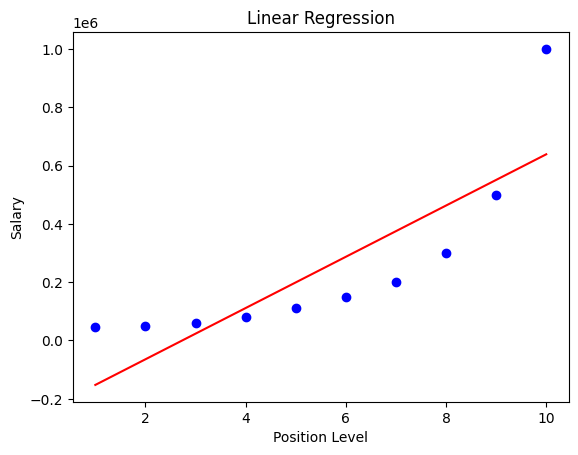

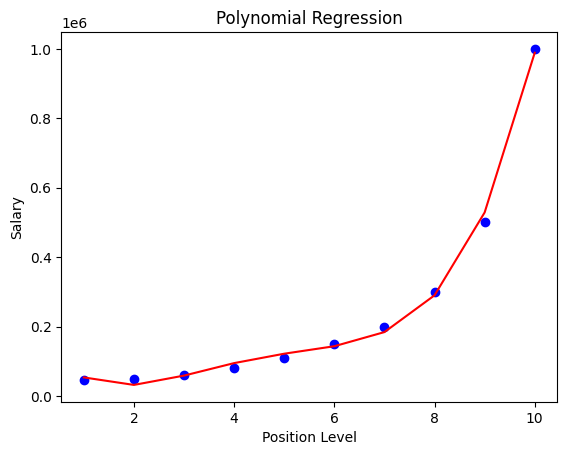

linear model prediction:  [331012.93103448]
polynomial model prediction:  [158862.45265155]


C:\Users\nedyk\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [35]:
# Polynomial Regression
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

data = pd.read_csv('csv_files/position_salaries.csv')
# print(data.info())
print(data.head())
x = data.iloc[:, 1:2]
y = data.iloc[:, 2]

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)
lr = LinearRegression()
model = lr.fit(xtrain, ytrain)

plt.scatter(x, y, color='blue')
# print("x shape: ",x.shape)
# print("y shape: ",y.shape)


plt.plot(x, model.predict(x), color='red')
plt.title('Linear Regression')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

poly = PolynomialFeatures(degree=4)
x_poly = poly.fit_transform(x)
# print("x_poly shape: ", x_poly.shape)
poly_model = LinearRegression()
poly_model.fit(x_poly, y)

plt.scatter(x, y, color='blue')
# print("x shape: ",x.shape)
# print("y shape: ",y.shape)
# print("x_poly shape: ",x_poly.shape)
plt.plot(x, poly_model.predict(x_poly), color='red')
plt.title('Polynomial Regression')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

print("linear model prediction: ", model.predict([[6.5]]))
print("polynomial model prediction: ", poly_model.predict(poly.fit_transform([[6.5]])))